In [1]:
import os
import pandas as pd

# "data/raw" klasöründeki tüm .csv dosyalarını oku
# Bir üst klasöre (root) çık ve sonra data/raw'a gir
raw_data_dir = os.path.join("..", "data", "raw")
csv_files = [f for f in os.listdir(raw_data_dir) if f.endswith('.csv')]

dataframes = {}
for file in csv_files:
    file_path = os.path.join(raw_data_dir, file)
    df_name = os.path.splitext(file)[0]
    
    try:
        # Virgül (,) yerine ayırıcı farklı olabilir (örneğin MovieLens'te :: kullanılır)
        # on_bad_lines='skip' hatalı satırları atlar, sep=None ise ayırıcıyı otomatik tahmin etmeye çalışır
        dataframes[df_name] = pd.read_csv(
            file_path, 
            encoding='latin-1', 
            sep=None, 
            engine='python', 
            on_bad_lines='warn' # Hatalı satır varsa uyarı verip geçecek
        )
        print(f"{file} yüklendi, shape: {dataframes[df_name].shape}")
        
    except Exception as e:
        print(f"{file} yüklenirken hata oluştu: {e}")

movies.csv yüklendi, shape: (3883, 4)
ratings.csv yüklendi, shape: (1000209, 4)
users.csv yüklendi, shape: (6040, 5)


In [2]:
# Sütun isimleri ve ilk 5 satırı kontrol edelim
for name, df in dataframes.items():
    print(f"\n--- {name} Veri Seti ---")
    print(df.head())


--- movies Veri Seti ---
   movieId                               title                        genres  \
0        1                    Toy Story (1995)   Animation|Children's|Comedy   
1        2                      Jumanji (1995)  Adventure|Children's|Fantasy   
2        3             Grumpier Old Men (1995)                Comedy|Romance   
3        4            Waiting to Exhale (1995)                  Comedy|Drama   
4        5  Father of the Bride Part II (1995)                        Comedy   

  Unnamed: 3  
0        NaN  
1        NaN  
2        NaN  
3        NaN  
4        NaN  

--- ratings Veri Seti ---
   userId  movieId  rating  timestamp
0       1     1193       5  978300760
1       1      661       3  978302109
2       1      914       3  978301968
3       1     3408       4  978300275
4       1     2355       5  978824291

--- users Veri Seti ---
   userId gender  age  occupation zip-code
0       1      F    1          10    48067
1       2      M   56          16    

In [3]:
for name, df in dataframes.items():
    print(f"\n--- {name} Eksik Değer Analizi ---")
    print(df.isnull().sum())


--- movies Eksik Değer Analizi ---
movieId          0
title            0
genres           0
Unnamed: 3    3882
dtype: int64

--- ratings Eksik Değer Analizi ---
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

--- users Eksik Değer Analizi ---
userId        0
gender        0
age           0
occupation    0
zip-code      0
dtype: int64


In [4]:
# Sadece movies tablosundaki o sütunu silelim
if 'Unnamed: 3' in dataframes['movies'].columns:
    dataframes['movies'] = dataframes['movies'].drop(columns=['Unnamed: 3'])
    print("Gereksiz sütun başarıyla silindi.")

Gereksiz sütun başarıyla silindi.


In [5]:
# ratings ve movies tablolarını birleştir
movie_ratings = pd.merge(dataframes['ratings'], dataframes['movies'], on='movieId')

# İlk 5 satıra bakalım
print(movie_ratings.head())

   userId  movieId  rating  timestamp                                   title  \
0       1     1193       5  978300760  One Flew Over the Cuckoo's Nest (1975)   
1       1      661       3  978302109        James and the Giant Peach (1996)   
2       1      914       3  978301968                     My Fair Lady (1964)   
3       1     3408       4  978300275                  Erin Brockovich (2000)   
4       1     2355       5  978824291                    Bug's Life, A (1998)   

                         genres  
0                         Drama  
1  Animation|Children's|Musical  
2               Musical|Romance  
3                         Drama  
4   Animation|Children's|Comedy  


In [6]:
# Film başına ortalama puanı ve kaç kişinin puan verdiğini hesaplayalım
movie_stats = movie_ratings.groupby('title').agg({'rating': ['mean', 'count']})

# Sütun isimlerini düzeltelim (Pandas agg sonrası karmaşıklaşabiliyor)
movie_stats.columns = ['avg_rating', 'rating_count']

# En az 100 kişinin puan verdiği, en yüksek puanlı 10 filme bakalım
popular_high_rated = movie_stats[movie_stats['rating_count'] > 100].sort_values(by='avg_rating', ascending=False)
print(popular_high_rated.head(10))

                                                    avg_rating  rating_count
title                                                                       
Seven Samurai (The Magnificent Seven) (Shichini...    4.560510           628
Shawshank Redemption, The (1994)                      4.554558          2227
Godfather, The (1972)                                 4.524966          2223
Close Shave, A (1995)                                 4.520548           657
Usual Suspects, The (1995)                            4.517106          1783
Schindler's List (1993)                               4.510417          2304
Wrong Trousers, The (1993)                            4.507937           882
Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)         4.491489           470
Raiders of the Lost Ark (1981)                        4.477725          2514
Rear Window (1954)                                    4.476190          1050


In [7]:
print(popular_high_rated.info())

<class 'pandas.DataFrame'>
Index: 1991 entries, Seven Samurai (The Magnificent Seven) (Shichinin no samurai) (1954) to Kazaam (1996)
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   avg_rating    1991 non-null   float64
 1   rating_count  1991 non-null   int64  
dtypes: float64(1), int64(1)
memory usage: 46.7+ KB
None


In [8]:
print(popular_high_rated.describe())

        avg_rating  rating_count
count  1991.000000   1991.000000
mean      3.400654    472.605726
std       0.577675    498.450627
min       1.466667    101.000000
25%       3.017800    182.000000
50%       3.475806    316.000000
75%       3.844648    591.000000
max       4.560510  11114.000000


In [9]:
print(movie_ratings.describe())

             userId       movieId        rating     timestamp
count  1.000209e+06  1.000209e+06  1.000209e+06  1.000209e+06
mean   3.024512e+03  1.865540e+03  3.581564e+00  9.722437e+08
std    1.728413e+03  1.096041e+03  1.117102e+00  1.215256e+07
min    1.000000e+00  1.000000e+00  1.000000e+00  9.567039e+08
25%    1.506000e+03  1.030000e+03  3.000000e+00  9.653026e+08
50%    3.070000e+03  1.835000e+03  4.000000e+00  9.730180e+08
75%    4.476000e+03  2.770000e+03  4.000000e+00  9.752209e+08
max    6.040000e+03  3.952000e+03  5.000000e+00  1.046455e+09


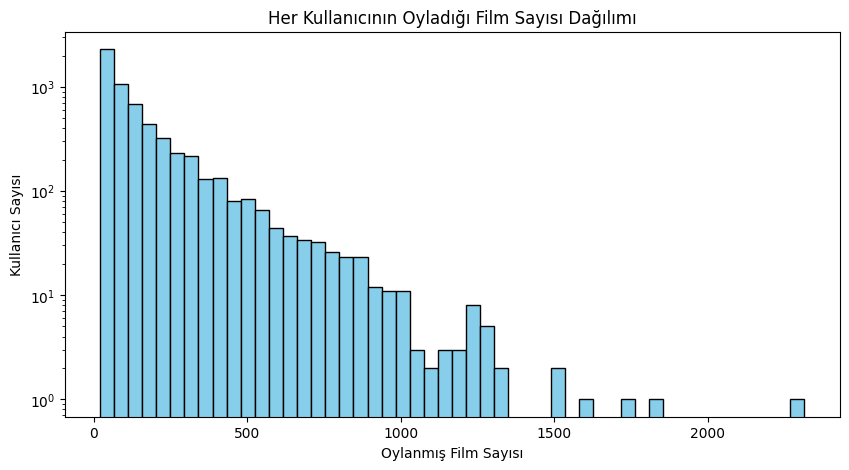

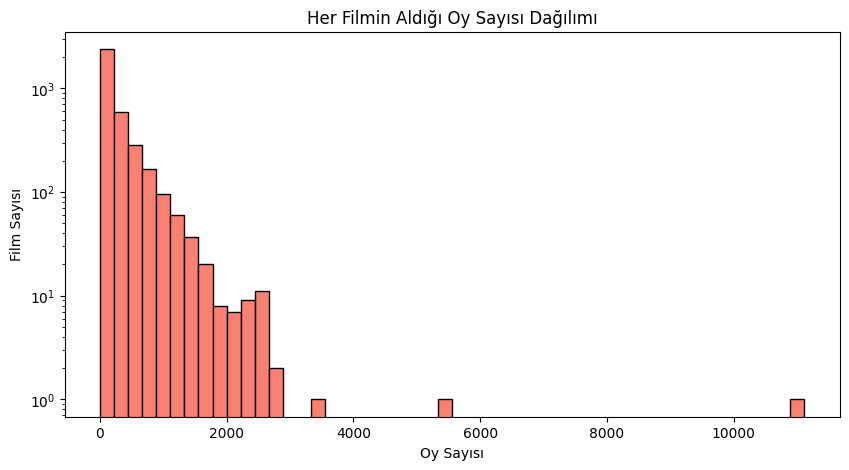

In [10]:
import matplotlib.pyplot as plt

# Kullanıcılar kaç filmi oylamış? (Her kullanıcının kaç rating yaptığı)
user_rating_counts = movie_ratings.groupby('userId')['rating'].count()

plt.figure(figsize=(10,5))
plt.hist(user_rating_counts, bins=50, color='skyblue', edgecolor='black')
plt.title('Her Kullanıcının Oyladığı Film Sayısı Dağılımı')
plt.xlabel('Oylanmış Film Sayısı')
plt.ylabel('Kullanıcı Sayısı')
plt.yscale('log')
plt.show()

# Filmler kaç kere oylanmış? (Her filmin kaç rating aldığı)
movie_rating_counts = movie_ratings.groupby('title')['rating'].count()

plt.figure(figsize=(10,5))
plt.hist(movie_rating_counts, bins=50, color='salmon', edgecolor='black')
plt.title('Her Filmin Aldığı Oy Sayısı Dağılımı')
plt.xlabel('Oy Sayısı')
plt.ylabel('Film Sayısı')
plt.yscale('log')
plt.show()

In [11]:
# 1. TEMİZLİK: Eşik değeri 50 olarak belirleyelim
user_counts = movie_ratings['userId'].value_counts()
active_users = user_counts[user_counts >= 50].index
movie_ratings_filtered = movie_ratings[movie_ratings['userId'].isin(active_users)]

movie_counts = movie_ratings_filtered['title'].value_counts()
popular_movies = movie_counts[movie_counts >= 50].index
final_df = movie_ratings_filtered[movie_ratings_filtered['title'].isin(popular_movies)]

# 2. PİVOT MATRİS OLUŞTURMA
# Satırlar kullanıcılar, sütunlar filmler olacak şekilde tabloyu çeviriyoruz
user_movie_matrix = final_df.pivot_table(index='userId', columns='title', values='rating')

# Matrisin boyutuna ve ilk birkaç satırına bakalım
print(f"Matris Boyutu: {user_movie_matrix.shape}")
user_movie_matrix.head()

Matris Boyutu: (4297, 2462)


title,'Night Mother (1986),"'burbs, The (1989)",...And Justice for All (1979),10 Things I Hate About You (1999),101 Dalmatians (1961),101 Dalmatians (1996),12 Angry Men (1957),"13th Warrior, The (1999)",2 Days in the Valley (1996),20 Dates (1998),...,You've Got Mail (1998),Young Doctors in Love (1982),Young Frankenstein (1974),Young Guns (1988),Young Guns II (1990),"Young Poisoner's Handbook, The (1995)",Young Sherlock Holmes (1985),Your Friends and Neighbors (1998),Zero Effect (1998),eXistenZ (1999)
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,5.0,4.0,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
total_cells = user_movie_matrix.size
non_empty_cells = user_movie_matrix.notna().sum().sum()
sparsity = (1 - (non_empty_cells / total_cells)) * 100
print(f"Matrisin Seyreklik Oranı: %{sparsity:.2f}")

Matrisin Seyreklik Oranı: %91.42


In [13]:
import pandas as pd
import numpy as np
from scipy.sparse.linalg import svds

# --- 1. TEMİZLİK (Eşik Değer: 50) ---
user_counts = movie_ratings['userId'].value_counts()
active_users = user_counts[user_counts >= 50].index
movie_ratings_filtered = movie_ratings[movie_ratings['userId'].isin(active_users)]

movie_counts = movie_ratings_filtered['title'].value_counts()
popular_movies = movie_counts[movie_counts >= 50].index
final_df = movie_ratings_filtered[movie_ratings_filtered['title'].isin(popular_movies)]

# --- 2. PİVOT MATRİS OLUŞTURMA ---
user_movie_matrix = final_df.pivot_table(index='userId', columns='title', values='rating')

# --- 3. DENGELEME (Eksik olan değişkenimiz burada yaratılıyor) ---
user_movie_matrix_centered = user_movie_matrix.apply(lambda x: x - x.mean(), axis=1)
user_movie_matrix_norm = user_movie_matrix_centered.fillna(0)

# --- 4. SVD ALGORİTMASI İLE TAHMİN ---
matrix_values = user_movie_matrix_norm.to_numpy(dtype=float)

# k=50 gizli kategori (latent factor) buluyoruz
U, sigma, Vt = svds(matrix_values, k=50)

# Parçalanan matrisleri çarpıp tahminleri oluşturuyoruz
sigma_diag_matrix = np.diag(sigma)
predicted_ratings = np.dot(np.dot(U, sigma_diag_matrix), Vt)

# Kişisel ortalamaları geri ekliyoruz
user_ratings_mean = user_movie_matrix.mean(axis=1).values.reshape(-1, 1)
final_predictions = predicted_ratings + user_ratings_mean

# Sonucu okunabilir tabloya çeviriyoruz
predictions_df = pd.DataFrame(final_predictions, 
                              columns=user_movie_matrix.columns, 
                              index=user_movie_matrix.index)

print("Matris başarıyla oluşturuldu ve SVD ile dolduruldu! Boyut:", predictions_df.shape)

from scipy.sparse.linalg import svds
import numpy as np
import pandas as pd

# 1. Ortalamadan arındırılmış (dengelenmiş) matrisimizi Numpy formatına alıyoruz
matrix_values = user_movie_matrix_norm.to_numpy(dtype=float)

# 2. SVD Algoritması!
# k=50 demek: Bilgisayara "Bana 4000 filmi temsil edecek 50 tane gizli kategori bul" diyoruz.
U, sigma, Vt = svds(matrix_values, k=50)

# 3. Parçalanan matrisleri tekrar çarparak TAHMİN tablosunu oluşturuyoruz (Boşluklar doluyor!)
sigma_diag_matrix = np.diag(sigma)
predicted_ratings = np.dot(np.dot(U, sigma_diag_matrix), Vt)

# 4. Hatırlarsan dengeleme yaparken herkesin ortalamasını çıkarmıştık.
# Şimdi o "kişisel ortalamaları" tahminlere geri ekliyoruz ki puanlar tekrar 1-5 arasına otursun.
user_ratings_mean = user_movie_matrix.mean(axis=1).values.reshape(-1, 1)
final_predictions = predicted_ratings + user_ratings_mean

# 5. Sonucu okunabilir bir Pandas DataFrame'ine çeviriyoruz
predictions_df = pd.DataFrame(final_predictions, 
                              columns=user_movie_matrix.columns, 
                              index=user_movie_matrix.index)

print("İşlem Tamam! Tüm matris sihirli bir şekilde dolduruldu.")

Matris başarıyla oluşturuldu ve SVD ile dolduruldu! Boyut: (4297, 2462)
İşlem Tamam! Tüm matris sihirli bir şekilde dolduruldu.


In [14]:
from sklearn.decomposition import TruncatedSVD

# --- 4. SVD ALGORİTMASI İLE TAHMİN (Sklearn Versiyonu) ---

# k=50 gizli kategori (n_components) bulacak SVD modelimizi kuruyoruz
svd = TruncatedSVD(n_components=50, random_state=42)

# Modeli matrisimize uygulayıp ikiye parçalıyoruz
# user_features: Kullanıcıların 50 gizli kategoriye olan ilgisi
user_features = svd.fit_transform(matrix_values) 

# movie_features: Filmlerin o 50 gizli kategoriyi ne kadar barındırdığı
movie_features = svd.components_ 

# Parçalanan matrisleri çarpıp o %91'lik boşluğu tahminlerle dolduruyoruz
predicted_ratings = np.dot(user_features, movie_features)

# Hatırlarsan dengeleme yaparken herkesin ortalamasını çıkarmıştık.
# Şimdi o "kişisel ortalamaları" tahminlere geri ekliyoruz.
final_predictions = predicted_ratings + user_ratings_mean

# Sonucu okunabilir bir Pandas DataFrame'ine çeviriyoruz
predictions_df = pd.DataFrame(final_predictions, 
                              columns=user_movie_matrix.columns, 
                              index=user_movie_matrix.index)

print("Kriz çözüldü! Matris başarıyla dolduruldu. Boyut:", predictions_df.shape)

Kriz çözüldü! Matris başarıyla dolduruldu. Boyut: (4297, 2462)


In [15]:
from sklearn.decomposition import TruncatedSVD
import numpy as np
import pandas as pd

# 1. Matrisimiz zaten hafızada hazır! Doğrudan numpy dizisine çeviriyoruz:
matrix_values = user_movie_matrix_norm.to_numpy(dtype=float)

# 2. Sklearn ile SVD (Hata vermeyen, daha optimize versiyon)
svd = TruncatedSVD(n_components=50, random_state=42)
user_features = svd.fit_transform(matrix_values) 
movie_features = svd.components_ 

# 3. Matrisleri çarpıp boşlukları dolduruyoruz
predicted_ratings = np.dot(user_features, movie_features)

# 4. Kişisel ortalamaları geri ekliyoruz ki puanlar 1-5 arasına otursun
# (user_movie_matrix değişkenin de zaten hafızada duruyor)
user_ratings_mean = user_movie_matrix.mean(axis=1).values.reshape(-1, 1)
final_predictions = predicted_ratings + user_ratings_mean

# 5. Sonucu okunabilir bir tabloya çeviriyoruz
predictions_df = pd.DataFrame(final_predictions, 
                              columns=user_movie_matrix.columns, 
                              index=user_movie_matrix.index)

print("Veriyi baştan okumadan, kriz saniyeler içinde çözüldü! Boyut:", predictions_df.shape)

Veriyi baştan okumadan, kriz saniyeler içinde çözüldü! Boyut: (4297, 2462)


In [16]:
def get_movie_recommendations(user_id, predictions_df, original_matrix, num_recommendations=5):
    # 1. Kullanıcının tahmini puanlarını büyükten küçüğe sırala
    user_predictions = predictions_df.loc[user_id].sort_values(ascending=False)
    
    # 2. Kullanıcının orijinal matriste zaten puan verdiği (izlediği) filmleri bul
    # original_matrix'te NaN OLMAYAN (notna) filmler izlenmiş demektir
    user_watched = original_matrix.loc[user_id].dropna().index
    
    # 3. Zaten izlenen filmleri tahmin listesinden çıkar (drop)
    recommendations = user_predictions.drop(labels=user_watched, errors='ignore')
    
    # 4. Geriye kalan en yüksek puanlı 'num_recommendations' kadar filmi döndür
    return recommendations.head(num_recommendations)

print("Öneri fonksiyonumuz hazır!")

Öneri fonksiyonumuz hazır!


In [ ]:
# Kullanıcı 42 için ilk 5 öneriyi isteyelim
user_id_to_test = 42 # Burayı istediğin bir ID ile değiştirebilirsin (1-4297 arası geçerli bir index olmalı)
top_movies = get_movie_recommendations(user_id_to_test, predictions_df, user_movie_matrix)

print(f"Kullanıcı {user_id_to_test} için SVD Modelinin Önerdiği En İyi 5 Film:\n")
print(top_movies)

Kullanıcı 42 için SVD Modelinin Önerdiği En İyi 5 Film:

title
Saving Private Ryan (1998)         4.246408
Airplane! (1980)                   4.239040
Sixth Sense, The (1999)            4.200312
Blair Witch Project, The (1999)    4.039722
Exorcist, The (1973)               4.034959
Name: 42, dtype: float64


In [18]:
# --- OPTION A: KULLANICI 42 GERÇEKTE NE İZLEMİŞ VE NE SEVMİŞ? ---
user_id_to_test = 42

print("--- OPTION A: GERÇEK ZEVKLER ---")
print(f"Kullanıcı {user_id_to_test}'nin Gerçekte 5 Puan Verdiği Bazı Filmler:")
real_favorites = user_movie_matrix.loc[user_id_to_test].dropna().sort_values(ascending=False)
print(real_favorites[real_favorites == 5.0].head(7))
print("\n" + "="*50 + "\n")

# --- OPTION B: POPÜLERLİK ÖNYARGISINI KIRMAK (GİZLİ CEVHERLER) ---
print("--- OPTION B: GİZLİ CEVHER (NİŞ) ÖNERİLER ---")

# 1. Çok popüler olan filmleri (örneğin sistemde 1000'den fazla oy alanları) tespit edelim
movie_vote_counts = movie_ratings_filtered['title'].value_counts()
too_popular_movies = movie_vote_counts[movie_vote_counts > 1000].index

# 2. Öneri fonksiyonumuzu biraz güncelleyelim
user_predictions = predictions_df.loc[user_id_to_test].sort_values(ascending=False)
user_watched = user_movie_matrix.loc[user_id_to_test].dropna().index

# Önce zaten izlediklerini çıkaralım
recommendations = user_predictions.drop(labels=user_watched, errors='ignore')

# Şimdi de "Çok Popüler" olan o ana akım filmleri (Godfather, Star Wars vb.) çıkaralım
niche_recommendations = recommendations.drop(labels=too_popular_movies, errors='ignore')

print(f"Herkesin izlediği popüler filmler elendikten sonra Kullanıcı {user_id_to_test} için En İyi 5 'Niş' Öneri:\n")
print(niche_recommendations.head(5))

--- OPTION A: GERÇEK ZEVKLER ---
Kullanıcı 42'nin Gerçekte 5 Puan Verdiği Bazı Filmler:
title
Close Encounters of the Third Kind (1977)    5.0
Better Off Dead... (1985)                    5.0
Blade Runner (1982)                          5.0
Caddyshack (1980)                            5.0
Spaceballs (1987)                            5.0
Silence of the Lambs, The (1991)             5.0
Contact (1997)                               5.0
Name: 42, dtype: float64


--- OPTION B: GİZLİ CEVHER (NİŞ) ÖNERİLER ---
Herkesin izlediği popüler filmler elendikten sonra Kullanıcı 42 için En İyi 5 'Niş' Öneri:

title
Exorcist, The (1973)          4.034959
Conan the Barbarian (1982)    3.921085
13th Warrior, The (1999)      3.912950
Army of Darkness (1993)       3.912697
Police Academy (1984)         3.911704
Name: 42, dtype: float64


In [21]:
from sklearn.metrics import mean_squared_error
import math

print("--- OPTION C: MODEL PERFORMANSI (RMSE) ---")

# Orijinal matriste gerçekten puan verilmiş (NaN olmayan) hücreleri buluyoruz
# NaN'ları filtrelemek için matrisi "tidy" (uzun) formata çeviriyoruz
actual_ratings = user_movie_matrix.stack().reset_index()
actual_ratings.columns = ['userId', 'title', 'actual_rating']

# Kendi modelimizin tahminlerini de aynı formata çeviriyoruz
predicted_ratings = predictions_df.stack().reset_index()
predicted_ratings.columns = ['userId', 'title', 'predicted_rating']

# Gerçek puanlar ile tahminleri eşleştiriyoruz (Sadece gerçekte izlenen filmler için)
evaluation_df = pd.merge(actual_ratings, predicted_ratings, on=['userId', 'title'])

# RMSE (Root Mean Square Error) Hesaplama
mse = mean_squared_error(evaluation_df['actual_rating'], evaluation_df['predicted_rating'])
rmse = math.sqrt(mse)

print(f"Modelimizin RMSE Skoru: {rmse:.4f}")

# Neden bu skoru aldık? Rastgele 5 filme bakıp gerçek ile tahmini kıyaslayalım:
print("\nÖrnek 5 Tahmin vs Gerçek Puan:")
print(evaluation_df.sample(5))

--- OPTION C: MODEL PERFORMANSI (RMSE) ---


ValueError: Input contains NaN.

In [20]:
from sklearn.metrics import mean_squared_error
import math

# Gerçek puanlar ve tahminleri birleştiriyoruz
evaluation_df = pd.merge(actual_ratings, predicted_ratings, on=['userId', 'title'])

# --- MİMARİ DOKUNUŞ: VERİ SANİTASYONU ---
# Önce sızıntının boyutuna bakalım
print("Temizlik Öncesi NaN Sayıları:\n", evaluation_df.isna().sum())

# NaN barındıran o sızıntı satırlarını acımadan siliyoruz
evaluation_df_clean = evaluation_df.dropna()

# Şimdi o tertemiz veriyle RMSE'yi güvenle hesaplayabiliriz
mse = mean_squared_error(evaluation_df_clean['actual_rating'], evaluation_df_clean['predicted_rating'])
rmse = math.sqrt(mse)

print(f"\n>>> Modelimizin Başarı Karnesi (RMSE): {rmse:.4f} <<<")

# Sistemin gerçekten ne yaptığını görmek için rastgele 5 filme bakalım:
print("\nÖrnek 5 Tahmin vs Gerçek Puan (Kullanıcılar ne vermiş, biz ne demiştik?):")
print(evaluation_df_clean.sample(5))

Temizlik Öncesi NaN Sayıları:
 userId                    0
title                     0
actual_rating       9671001
predicted_rating          0
dtype: int64

>>> Modelimizin Başarı Karnesi (RMSE): 0.8363 <<<

Örnek 5 Tahmin vs Gerçek Puan (Kullanıcılar ne vermiş, biz ne demiştik?):
         userId                                      title  actual_rating  \
3332690    1923                         Nurse Betty (2000)            1.0   
7459185    4250                        Program, The (1993)            4.0   
3929821    2247  Close Encounters of the Third Kind (1977)            4.0   
8737948    5000                 Bone Collector, The (1999)            4.0   
7099442    4041                        Multiplicity (1996)            3.0   

         predicted_rating  
3332690          3.248726  
7459185          4.056249  
3929821          4.261044  
8737948          4.301633  
7099442          3.054937  


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error
import math

# 1. Veriyi %80 Eğitim, %20 Test olarak bölüyoruz
train_data, test_data = train_test_split(final_df, test_size=0.2, random_state=42)

# 2. Sadece EĞİTİM verisiyle Pivot Matris oluşturuyoruz (Test verisini model hiç görmeyecek)
train_matrix = train_data.pivot_table(index='userId', columns='title', values='rating')

# 3. Eğitim matrisini dengeleyelim (Mean Centering)
train_matrix_centered = train_matrix.apply(lambda x: x - x.mean(), axis=1)
train_matrix_norm = train_matrix_centered.fillna(0)

# 4. SVD Uygulayalım (Eğitim seti üzerinde)
svd = TruncatedSVD(n_components=50, random_state=42)
train_matrix_values = train_matrix_norm.to_numpy(dtype=float)
user_features = svd.fit_transform(train_matrix_values)
movie_features = svd.components_

# 5. Tahminleri oluştur ve ortalamaları geri ekle
predicted_ratings_array = np.dot(user_features, movie_features)
user_train_mean = train_matrix.mean(axis=1).values.reshape(-1, 1)
final_train_predictions = predicted_ratings_array + user_train_mean

# Tahminleri DataFrame yapalım
train_preds_df = pd.DataFrame(final_train_predictions, 
                              columns=train_matrix.columns, 
                              index=train_matrix.index)

# 6. KRİTİK AN: Modelin hiç görmediği TEST verisindeki gerçek puanları tahminlerle kıyaslayalım
# Test verisindeki kullanıcı ve film eşleşmelerini tahmin matrisinden çekiyoruz
def get_prediction(row):
    try:
        return train_preds_df.loc[row['userId'], row['title']]
    except:
        return np.nan # Eğer eğitim setinde olmayan bir film/kullanıcı gelirse

test_data['predicted_rating'] = test_data.apply(get_prediction, axis=1)

# NaN olanları (eğitimde hiç görülmemiş yeni veriler) temizleyip RMSE hesaplayalım
test_data_clean = test_data.dropna(subset=['predicted_rating'])

rmse_real = math.sqrt(mean_squared_error(test_data_clean['rating'], test_data_clean['predicted_rating']))

print(f"\n>>> GERÇEK (KÖR TEST) RMSE SKORU: {rmse_real:.4f} <<<")
print(f"Test edilen örnek sayısı: {len(test_data_clean)}")


>>> GERÇEK (KÖR TEST) RMSE SKORU: 0.9567 <<<
Test edilen örnek sayısı: 184079


In [23]:
# 1. Seri / Devam Filmleri Bilgisi (Örnek Manuel Eşleme)
# Anahtar: Devam Filmi, Değer: İlk Film (Öncül)
movie_sequels = {
    "Star Wars: Episode V - The Empire Strikes Back (1980)": "Star Wars: Episode IV - A New Hope (1977)",
    "Godfather: Part II, The (1974)": "Godfather, The (1972)",
    "Star Wars: Episode VI - Return of the Jedi (1983)": "Star Wars: Episode V - The Empire Strikes Back (1980)",
    "Aliens (1986)": "Alien (1979)",
    "Terminator 2: Judgment Day (1991)": "Terminator, The (1984)"
}

def get_smart_recommendations(user_id, predictions_df, original_matrix, num_recommendations=5):
    # Tahminleri al ve sırala
    user_preds = predictions_df.loc[user_id].sort_values(ascending=False)
    # Zaten izlediklerini bul
    user_watched = original_matrix.loc[user_id].dropna().index.tolist()
    
    final_recs = []
    
    for movie, score in user_preds.items():
        if movie in user_watched:
            continue # Zaten izlemişse geç
            
        # --- SERİ KONTROLÜ (Mimar Dokunuşu) ---
        if movie in movie_sequels:
            prequel = movie_sequels[movie]
            if prequel not in user_watched:
                # Eğer ilk filmi izlemediyse, devam filmini önerme! 
                # (İstersen buraya 'önce ilkini izlemelisin' mesajı veya ilk filmi listeye ekleme mantığı kurabilirsin)
                continue 
        
        final_recs.append((movie, score))
        
        if len(final_recs) == num_recommendations:
            break
            
    return pd.Series(dict(final_recs))

print("Akıllı (Seri Kontrollü) Öneri Fonksiyonu Hazır!")

Akıllı (Seri Kontrollü) Öneri Fonksiyonu Hazır!


In [24]:
import joblib

# Gerekli tüm parçaları bir sözlükte toplayıp kaydedelim
model_data = {
    'predictions': predictions_df,
    'original_matrix': user_movie_matrix,
    'sequels': movie_sequels
}

joblib.dump(model_data, 'final_movie_recommender.pkl')
print("Model başarıyla kaydedildi! Artık tek satırla her yerde çalıştırabilirsin.")

Model başarıyla kaydedildi! Artık tek satırla her yerde çalıştırabilirsin.


In [25]:
# Kullanıcı 42 için Akıllı Öneri (Seri Kontrollü) test edelim
user_id_to_test = 42

print(f"--- KULLANICI {user_id_to_test} İÇİN AKILLI ÖNERİ LİSTESİ ---")
smart_recs = get_smart_recommendations(user_id_to_test, predictions_df, user_movie_matrix, num_recommendations=5)

print(smart_recs)

# Karşılaştırma için eski (saf SVD) listeyi de hatırlayalım:
# 1. Star Wars: Episode V
# 2. Raiders of the Lost Ark
# 3. Godfather, The
# 4. Star Wars: Episode IV
# 5. Godfather: Part II

--- KULLANICI 42 İÇİN AKILLI ÖNERİ LİSTESİ ---
Saving Private Ryan (1998)         4.246408
Airplane! (1980)                   4.239040
Sixth Sense, The (1999)            4.200312
Blair Witch Project, The (1999)    4.039722
Exorcist, The (1973)               4.034959
dtype: float64


In [ ]:
def get_balanced_recommendations(user_id, predictions_df, original_matrix, num_recommendations=5):
    user_preds = predictions_df.loc[user_id].sort_values(ascending=False)
    user_watched = original_matrix.loc[user_id].dropna().index.tolist()
    
    # Çok popülerleri (1000+ oy alanlar) belirle
    too_popular = movie_ratings_filtered['title'].value_counts()[movie_ratings_filtered['title'].value_counts() > 1000].index
    
    final_list = []
    
    # 1. Aşama: En iyi 3 filmi getir (Seri kontrolü yaparak ama popülerlik sınırı koymadan)
    for movie, score in user_preds.items():
        if movie in user_watched: continue
        
        # Seri kontrolü (İzlemediyse puanı kırıyoruz, silmiyoruz)
        adjusted_score = score
        if movie in movie_sequels and movie_sequels[movie] not in user_watched:
            adjusted_score *= 0.8 # %20 ceza puanı
            
        final_list.append({'title': movie, 'score': adjusted_score, 'type': 'Mainstream'})
        if len(final_list) == 3: break
            
    # 2. Aşama: Geri kalan 2 filmi "Niş" (Popüler olmayanlar) arasından seç
    niche_count = 0
    for movie, score in user_preds.items():
        if movie in user_watched or any(d['title'] == movie for d in final_list): continue
        
        if movie not in too_popular: # Sadece popüler olmayanı al
            final_list.append({'title': movie, 'score': score, 'type': 'Niche'})
            niche_count += 1
        if niche_count == 2: break
            
    return pd.DataFrame(final_list)

# Test edelim
balanced_recs = get_balanced_recommendations(user_id_to_test, predictions_df, user_movie_matrix)
print(balanced_recs)

                        title     score        type
0  Saving Private Ryan (1998)  4.246408  Mainstream
1            Airplane! (1980)  4.239040  Mainstream
2     Sixth Sense, The (1999)  4.200312  Mainstream
3        Exorcist, The (1973)  4.034959       Niche
4  Conan the Barbarian (1982)  3.921085       Niche


: 